In [53]:
import pandas as pd
import yfinance as yf
from datetime import date

def get_indices_daily_10y(tickers=("^FCHI", "^GSPC"), years=10):
    end = pd.Timestamp.today().normalize()
    start = end - pd.DateOffset(years=years)

    # Download daily OHLCV
    data = yf.download(
        list(tickers),
        start=start.strftime("%Y-%m-%d"),
        end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),  # include last day
        interval="1d",
        auto_adjust=False,
        group_by="ticker",
        threads=True,
        progress=False,
    )

    # Normalize to a flat dataframe: Date, Ticker, Open, High, Low, Close, Adj Close, Volume
    frames = []
    for t in tickers:
        df_t = data[t].copy()
        df_t["Ticker"] = t
        df_t = df_t.reset_index().rename(columns={"Date": "date"})
        frames.append(df_t)

    df = pd.concat(frames, ignore_index=True)

    # Add useful daily metrics
    df["mid_oc"] = (df["Open"] + df["Close"]) / 2.0                 # moyenne Open/Close
    #df["ohlc4"]  = (df["Open"] + df["High"] + df["Low"] + df["Close"]) / 4.0  # OHLC4
    #df["ret_close"] = df.groupby("Ticker")["Close"].pct_change()     # rendement close-to-close

    # Optional: keep clean ordering
    cols = ["date", "Ticker", "Open", "High", "Low", "Close", "Adj Close", "Volume",
            "mid_oc"#, "ohlc4", "ret_close"
           ]
    df = df[cols].sort_values(["Ticker", "date"]).reset_index(drop=True)
    return df


ticker_map = {
    "CW8.PA": "MSCI World",      # best global (✔ core ETF)

    "CAC.PA": "CAC 40",         # France (liquid, simple)
    "DAXEX.PA": "DAX",          # Germany (Amundi, clean)

    "ESE.PA": "S&P 500",        # US large cap (good replication)
    "PANX.PA": "Nasdaq-100",    # US tech

    "CNYA.L": "China MSCI",     # China (best liquid UCITS)

    "SGLN.L": "Gold"            # physical gold (best ETC EU)
}



df = get_indices_daily_10y(tickers=list(ticker_map.keys()), years=20)
df


$DAXEX.PA: possibly delisted; no timezone found

1 Failed download:
['DAXEX.PA']: possibly delisted; no timezone found


Price,date,Ticker,Open,High,Low,Close,Adj Close,Volume,mid_oc
0,2008-01-02,CAC.PA,56.270000,56.270000,56.270000,56.270000,38.184731,0.0,56.270000
1,2008-01-03,CAC.PA,55.639999,55.639999,55.639999,55.639999,37.757206,0.0,55.639999
2,2008-01-04,CAC.PA,55.590000,55.590000,55.590000,55.590000,37.723289,0.0,55.590000
3,2008-01-07,CAC.PA,54.599998,54.599998,54.599998,54.599998,37.051483,0.0,54.599998
4,2008-01-08,CAC.PA,54.660000,54.660000,54.660000,54.660000,37.092197,0.0,54.660000
...,...,...,...,...,...,...,...,...,...
32965,2026-05-08,SGLN.L,6750.000000,6761.000000,6701.566895,6705.000000,6705.000000,241971.0,6727.500000
32966,2026-05-11,SGLN.L,6677.000000,6758.359863,6634.987793,6727.000000,6727.000000,380917.0,6702.000000
32967,2026-05-12,SGLN.L,6729.000000,6756.798828,6664.668945,6690.000000,6690.000000,400073.0,6709.500000
32968,2026-05-13,SGLN.L,6748.000000,6762.000000,6707.207031,6736.000000,6736.000000,311855.0,6742.000000


| Platform       | Ticker                    |
| -------------- | ------------------------- |
| Yahoo Finance  | `^FCHI` ✅ (use in Python) |
| Google Finance | `INDEXEURO:PX1`           |
| TradingView    | `PX1`                     |
| Bloomberg      | `CAC INDEX`               |


In [54]:
df = df.dropna()

In [55]:
import matplotlib.pyplot as plt

In [56]:
df.Ticker  = df.Ticker .map(ticker_map)

C:\Users\a037702\AppData\Local\Temp\ipykernel_24200\2632419276.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Ticker  = df.Ticker .map(ticker_map)


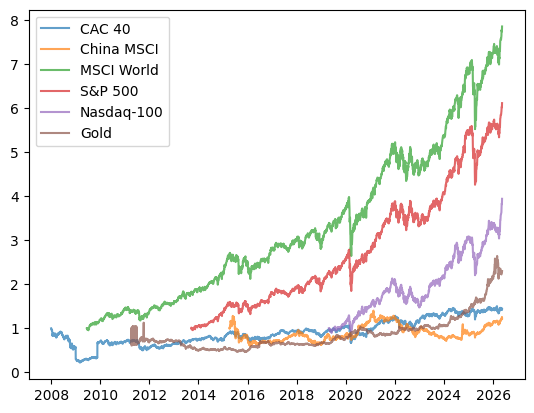

In [57]:
for c in df.Ticker	.unique(): 
    mask = df.Ticker==c
    x = df[mask].date.values
    y = df[mask].mid_oc.values
    y = y/y[0]
    
    plt.plot( x, y, label = c, alpha = 0.7)
plt.legend()

<Axes: xlabel='date'>

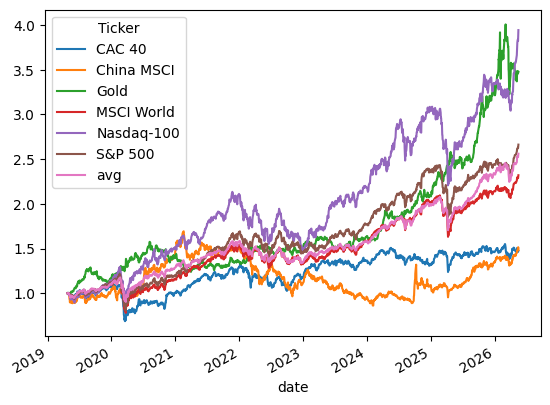

In [94]:

df2 = (df.loc[:, ["date", "Ticker", "mid_oc"]]
         .pivot(index="date", columns="Ticker", values="mid_oc")
         .sort_index()
      ).dropna().reset_index()
cols = df2.columns[1:]
df3= df2.copy()
df3[cols]= df3[cols]/df3[cols].iloc[0,:]
df3["avg"]= df3[cols].mean(axis = 1)
cols2= list(cols)+["avg"]
df3.plot(x= "date", y= cols2)

In [124]:
import numpy as np

In [96]:
df3.date.max()

Timestamp('2026-05-14 00:00:00')

In [129]:
#periode = 3  # years
#startoffset = 1.2 # years 
for periode in (2,3):
    for startoffset in np.arange(0,5, 1/12): 
        df3["date"] = pd.to_datetime(df3["date"])
        datemin = df3.date.min() + pd.DateOffset(days=int((periode+startoffset)*365))
        datemax = datemin + pd.DateOffset(days=int((periode)*365))
        #datestart = min((datemin, df3.date.max()))
        if datemax <= df3.date.max():
            m1= df3.date >= datemin
            m2= df3.date <= datemax
            tab = df3[m1 & m2]
            diff = tab.avg   .iloc[-1] - tab.avg   .iloc[0]
            print(periode, datemin.date(), datemax.date(), f'{int(100*diff)}%')

2 2021-04-24 2023-04-24 8%
2 2021-05-24 2023-05-24 9%
2 2021-06-23 2023-06-23 8%
2 2021-07-24 2023-07-24 8%
2 2021-08-23 2023-08-23 4%
2 2021-09-23 2023-09-23 5%
2 2021-10-23 2023-10-23 0%
2 2021-11-22 2023-11-22 -3%
2 2021-12-23 2023-12-23 1%
2 2022-01-22 2024-01-22 12%
2 2022-02-22 2024-02-22 21%
2 2022-03-24 2024-03-23 23%
2 2022-04-24 2024-04-23 29%
2 2022-05-24 2024-05-23 43%
2 2022-06-23 2024-06-22 47%
2 2022-07-24 2024-07-23 41%
2 2022-08-23 2024-08-22 33%
2 2022-09-23 2024-09-22 44%
2 2022-10-23 2024-10-22 58%
2 2022-11-22 2024-11-21 57%
2 2022-12-23 2024-12-22 63%
2 2023-01-22 2025-01-21 60%
2 2023-02-22 2025-02-21 64%
2 2023-03-24 2025-03-23 49%
2 2023-04-24 2025-04-23 36%
2 2023-05-24 2025-05-23 46%
2 2023-06-23 2025-06-22 45%
2 2023-07-24 2025-07-23 50%
2 2023-08-23 2025-08-22 56%
2 2023-09-23 2025-09-22 65%
2 2023-10-23 2025-10-22 78%
2 2023-11-22 2025-11-21 70%
2 2023-12-23 2025-12-22 75%
2 2024-01-22 2026-01-21 78%
2 2024-02-22 2026-02-21 75%
2 2024-03-23 2026-03-23 51%


2 2021-04-24 2023-04-24 8%
2 2021-05-24 2023-05-24 9%
2 2021-06-23 2023-06-23 8%
2 2021-07-24 2023-07-24 8%
2 2021-08-23 2023-08-23 4%
2 2021-09-23 2023-09-23 5%
2 2021-10-23 2023-10-23 0%
2 2021-11-22 2023-11-22 -3%
2 2021-12-23 2023-12-23 1%
2 2022-01-22 2024-01-22 12%
2 2022-02-22 2024-02-22 21%
2 2022-03-24 2024-03-23 23%
2 2022-04-24 2024-04-23 29%
2 2022-05-24 2024-05-23 43%
2 2022-06-23 2024-06-22 47%
2 2022-07-24 2024-07-23 41%
2 2022-08-23 2024-08-22 33%
2 2022-09-23 2024-09-22 44%
2 2022-10-23 2024-10-22 58%
2 2022-11-22 2024-11-21 57%
2 2022-12-23 2024-12-22 63%
2 2023-01-22 2025-01-21 60%
2 2023-02-22 2025-02-21 64%
2 2023-03-24 2025-03-23 49%
2 2023-04-24 2025-04-23 36%
2 2023-05-24 2025-05-23 46%
2 2023-06-23 2025-06-22 45%
2 2023-07-24 2025-07-23 50%
2 2023-08-23 2025-08-22 56%
2 2023-09-23 2025-09-22 65%
2 2023-10-23 2025-10-22 78%
2 2023-11-22 2025-11-21 70%
2 2023-12-23 2025-12-22 75%
2 2024-01-22 2026-01-21 78%
2 2024-02-22 2026-02-21 75%
2 2024-03-23 2026-03-23 51%


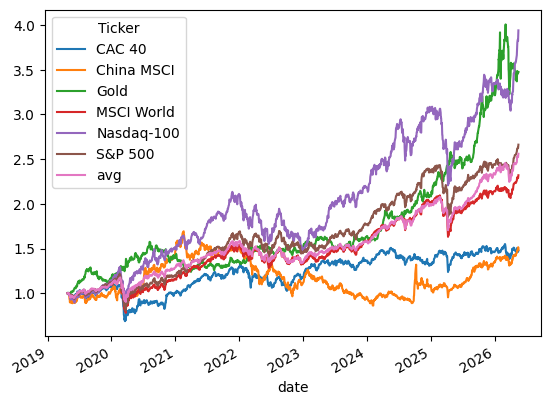

In [131]:
import numpy as np
import matplotlib.pyplot as plt

df = df.dropna()
df.Ticker  = df.Ticker .map(ticker_map)

df2 = (df.loc[:, ["date", "Ticker", "mid_oc"]]
         .pivot(index="date", columns="Ticker", values="mid_oc")
         .sort_index()
      ).dropna().reset_index()
cols = df2.columns[1:]
df3= df2.copy()
df3[cols]= df3[cols]/df3[cols].iloc[0,:]
df3["avg"]= df3[cols].mean(axis = 1)
cols2= list(cols)+["avg"]
df3.plot(x= "date", y= cols2)

#periode = 3  # years
#startoffset = 1.2 # years 
for periode in (2,3):
    for startoffset in np.arange(0,5, 1/12): 
        df3["date"] = pd.to_datetime(df3["date"])
        datemin = df3.date.min() + pd.DateOffset(days=int((periode+startoffset)*365))
        datemax = datemin + pd.DateOffset(days=int((periode)*365))
        #datestart = min((datemin, df3.date.max()))
        if datemax <= df3.date.max():
            m1= df3.date >= datemin
            m2= df3.date <= datemax
            tab = df3[m1 & m2]
            diff = tab.avg   .iloc[-1] - tab.avg   .iloc[0]
            print(periode, datemin.date(), datemax.date(), f'{int(100*diff)}%')

# flat tax

                        min        max  count
Ticker                                       
CAC 40           2018-12-13 2026-05-14   1897
DAX              2016-05-16 2026-05-14   2558
Gold             2016-05-16 2026-05-14   2526
STOXX Europe 600 2024-02-19 2026-05-14    569
df2 shape: (560, 5)
        date     CAC 40         DAX    Gold  STOXX Europe 600
0 2024-02-19  36.261000  157.580002  3114.5        223.495003
1 2024-02-20  36.400501  157.480003  3121.5        223.529999
2 2024-02-21  36.532000  157.809998  3122.5        223.264999
3 2024-02-22  36.910999  159.989998  3115.5        225.305000
4 2024-02-23  37.141500  160.540001  3113.5        225.895004

Weights:
CAC 40              16.67
DAX                 16.67
Gold                50.00
STOXX Europe 600    16.67
dtype: float64


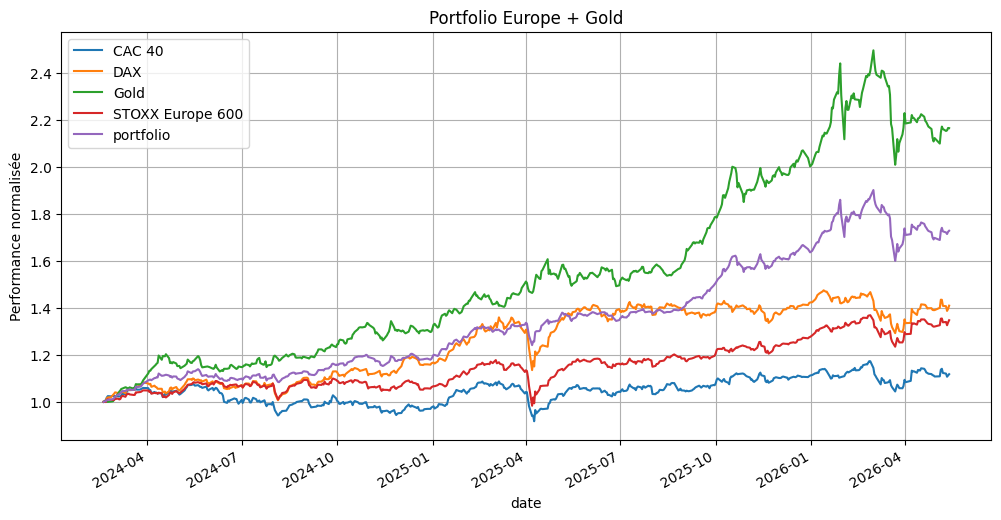


===== PERIODE 2 ANS =====

===== PERIODE 3 ANS =====


In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# ETF portfolio Europe + Gold
# 1€ CAC40, 1€ DAX, 1€ STOXX Europe 600, 3€ Gold
# =========================

ticker_map = {
    "CACC.PA": "CAC 40",
    "DAX.PA": "DAX",
    "MEUD.PA": "STOXX Europe 600",
    "SGLN.L": "Gold"
}

tickers = tuple(ticker_map.keys())

# fonction principale inchangée
df = get_indices_daily_10y(tickers=tickers, years=10)

df = df.dropna().copy()
df["Ticker"] = df["Ticker"].map(ticker_map)
df = df.dropna(subset=["Ticker"])

# diagnostic rapide
print(
    df.groupby("Ticker")["date"]
      .agg(["min", "max", "count"])
)

# =========================
# Pivot
# =========================

df2 = (df.loc[:, ["date", "Ticker", "mid_oc"]]
         .pivot_table(index="date", columns="Ticker", values="mid_oc", aggfunc="mean")
         .sort_index()
      )

# garder seulement la période commune
df2 = df2.dropna().reset_index()
df2.columns.name = None

print("df2 shape:", df2.shape)
print(df2.head())

cols = df2.columns[1:]

# =========================
# Normalize base 1
# =========================

df3 = df2.copy()
df3[cols] = df3[cols] / df3[cols].iloc[0, :]

# =========================
# Weights: Gold = 3€, rest = 1€
# =========================

weights = pd.Series(1.0, index=cols)
weights["Gold"] = 3.0
weights = weights / weights.sum()

print("\nWeights:")
print((weights * 100).round(2))

df3["portfolio"] = df3[cols].mul(weights, axis=1).sum(axis=1)

cols2 = list(cols) + ["portfolio"]

# =========================
# Plot
# =========================

ax = df3.plot(x="date", y=cols2, figsize=(12, 6))
ax.set_title("Portfolio Europe + Gold")
ax.set_ylabel("Performance normalisée")
ax.grid(True)
plt.show()

# =========================
# Brut + flat tax 30%
# =========================

df3["date"] = pd.to_datetime(df3["date"])

for periode in (2, 3):
    print(f"\n===== PERIODE {periode} ANS =====")

    for startoffset in np.arange(0, 5, 1/12):
        datemin = df3.date.min() + pd.DateOffset(days=int((periode + startoffset) * 365))
        datemax = datemin + pd.DateOffset(days=int(periode * 365))

        if datemax <= df3.date.max():
            m1 = df3.date >= datemin
            m2 = df3.date <= datemax
            tab = df3[m1 & m2]

            if len(tab) < 2:
                continue

            ret_brut = tab["portfolio"].iloc[-1] / tab["portfolio"].iloc[0] - 1

            # flat tax 30% uniquement si gain positif
            ret_net = ret_brut * 0.70 if ret_brut > 0 else ret_brut

            print(
                periode,
                datemin.date(),
                datemax.date(),
                f"brut={ret_brut*100:.0f}%",
                f"net_flat_tax={ret_net*100:.0f}%"
            )

In [133]:
df3

Ticker,date,CAC 40,Gold,STOXX Europe 600,portfolio
0,2026-05-14,1.0,1.0,1.0,1.0
